## Problématique 

## Objectif
L'objectif de ce projet est de construire un système de segmentation client intelligent capable d’identifier des groupes de clients homogènes afin de personnaliser les actions marketing et améliorer le ROI des campagnes.

- Dataset utilisé : kaggle.com/datasets/mashlyn/online-retail-ii-uci

## KPI à atteindre
- Silhouette score >= 0.45
- Nombre de clusters entre 3 et 6
- Chaque cluster doit avoir une interprétation business claire
- Segments exploitables en actions marketing concrètes

## QUESTIONS BUSINESS
- Combien de segments clients distincts existent réellement ?
- Qui sont les clients VIP à forte valeur ?
- Qui sont les clients dormants à risque de churn ?
- Quels clients sont les plus sensibles aux promotions ?
- Quelle stratégie marketing appliquer à chaque segment ?

## Livrables attendus
- Notebook propre avec EDA et insights business
- Feature engineering RFM complet (Recency, Frequency, Monetary)
- Prétraitement dans un pipeline sklearn
- Au moins 3 approches testées : K-Means, DBSCAN, Clustering Hiérarchique
- Sélection du nombre optimal de clusters (Elbow + Silhouette)
- Réduction de dimension avec PCA
- Visualisation 2D des segments avec t-SNE
- Visualisation interactive Plotly avec survol des profils clients
- Tableau final de profilage marketing par segment (nom + stratégie)
- Résumé final orienté business prêt à partager à l’équipe commerciale



## Analyse Exploratoire des données 

#### Import des bibliothèques 

In [3]:
# import des bibliothèques 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer


#### Compréhension des données 

In [4]:
df = pd.read_csv('online_retail_II.csv')
print('='*50)
print(df.info())

print('='*50)
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
(1067371, 8)


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [5]:


# Renommage des colonnes en français
mapping_colonnes = {
    'Invoice': 'Facture',
    'StockCode': 'Code_Produit',
    'Description': 'Description',
    'Quantity': 'Quantite',
    'InvoiceDate': 'Date_Facture',
    'Price': 'Prix_Unitaire',
    'Customer ID': 'ID_Client',
    'Country': 'Pays'
}
df = df.rename(columns=mapping_colonnes)

print('=' * 50)
print(df.info())
print('=' * 50)
print(df.shape)
print('Colonnes renommées :')
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Facture        1067371 non-null  object 
 1   Code_Produit   1067371 non-null  object 
 2   Description    1062989 non-null  object 
 3   Quantite       1067371 non-null  int64  
 4   Date_Facture   1067371 non-null  object 
 5   Prix_Unitaire  1067371 non-null  float64
 6   ID_Client      824364 non-null   float64
 7   Pays           1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
(1067371, 8)
Colonnes renommées :
['Facture', 'Code_Produit', 'Description', 'Quantite', 'Date_Facture', 'Prix_Unitaire', 'ID_Client', 'Pays']


#### Détection des valeurs manquantes 

In [6]:
somme_missing = df.isnull().sum()
pourcentage = somme_missing / len(df) * 100
tableau_missing = pd.DataFrame(
    {
        'Somme': somme_missing , 
    'Pourcentage': pourcentage 
    }
)
print(tableau_missing)

                Somme  Pourcentage
Facture             0     0.000000
Code_Produit        0     0.000000
Description      4382     0.410541
Quantite            0     0.000000
Date_Facture        0     0.000000
Prix_Unitaire       0     0.000000
ID_Client      243007    22.766873
Pays                0     0.000000


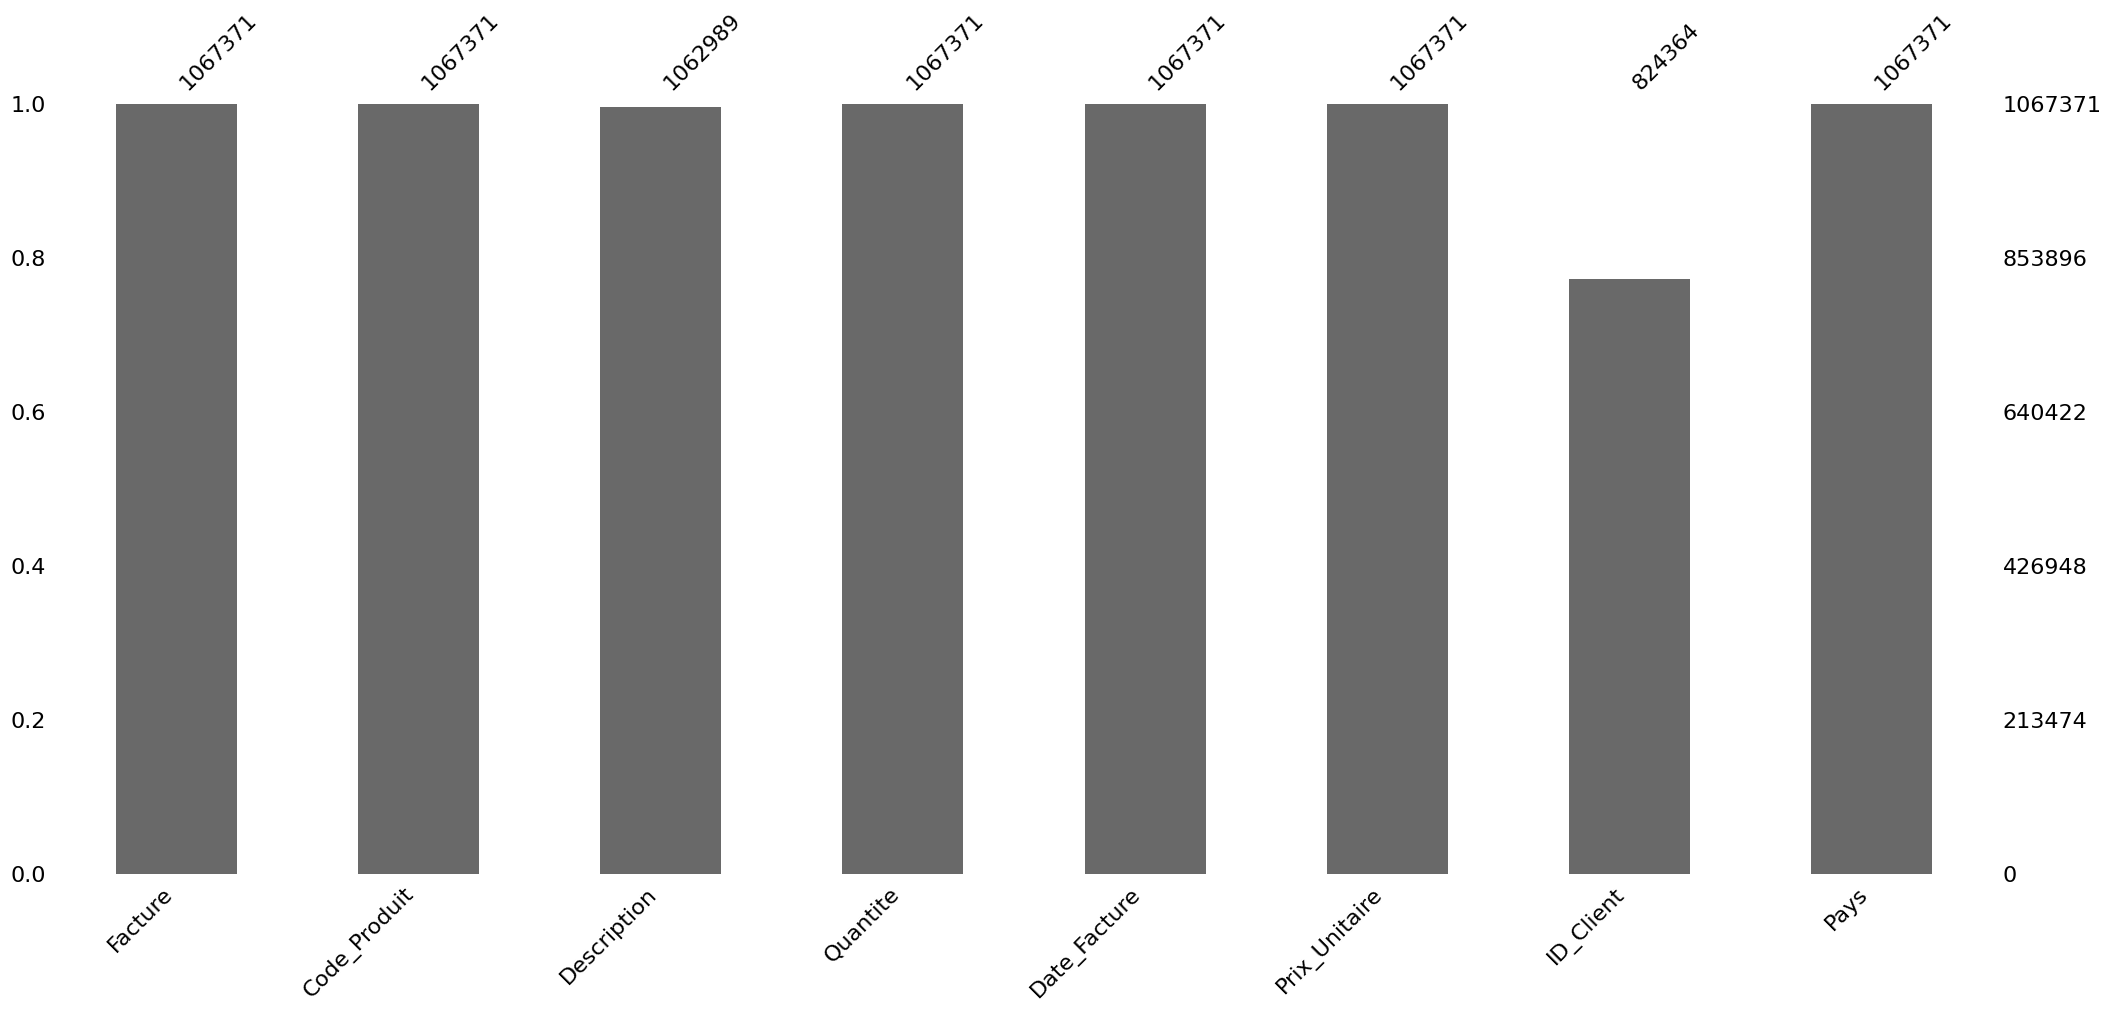

In [6]:
# visualisation des données manquantes 
msno.bar(df)
plt.savefig('images/missing_values_bar.png')


<Axes: >

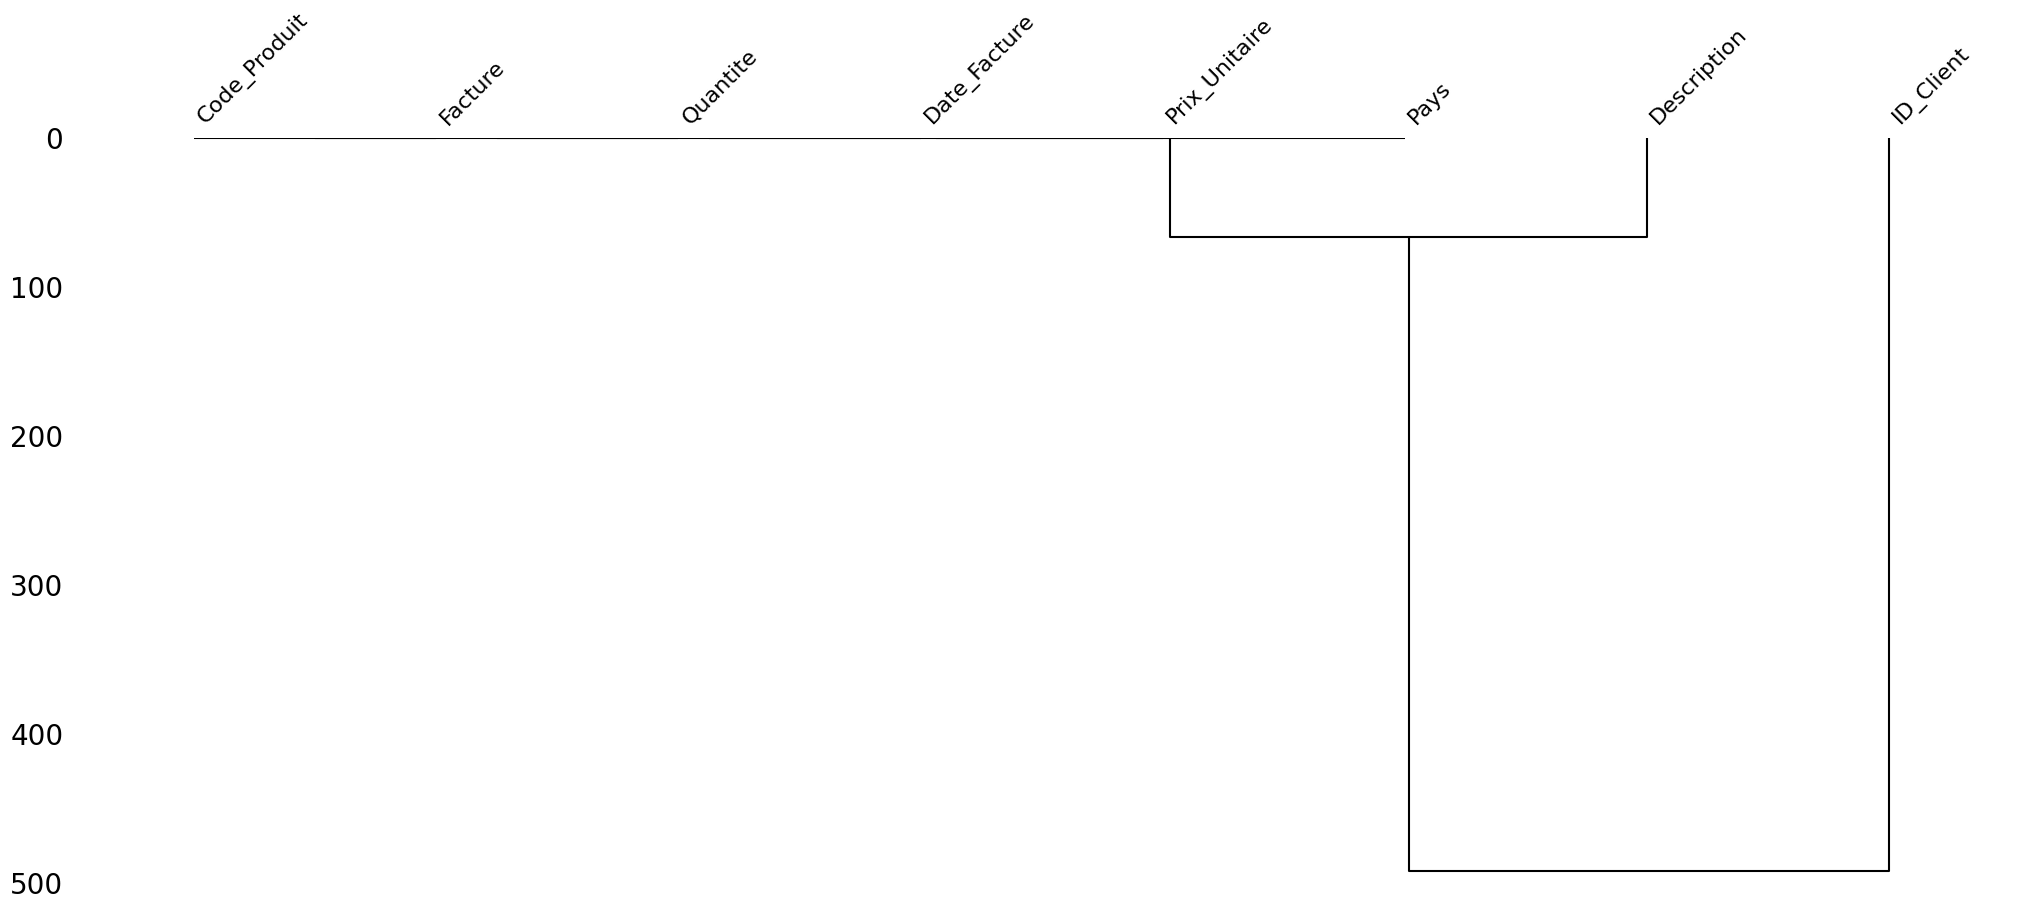

In [8]:
msno.dendrogram(df)

<Axes: >

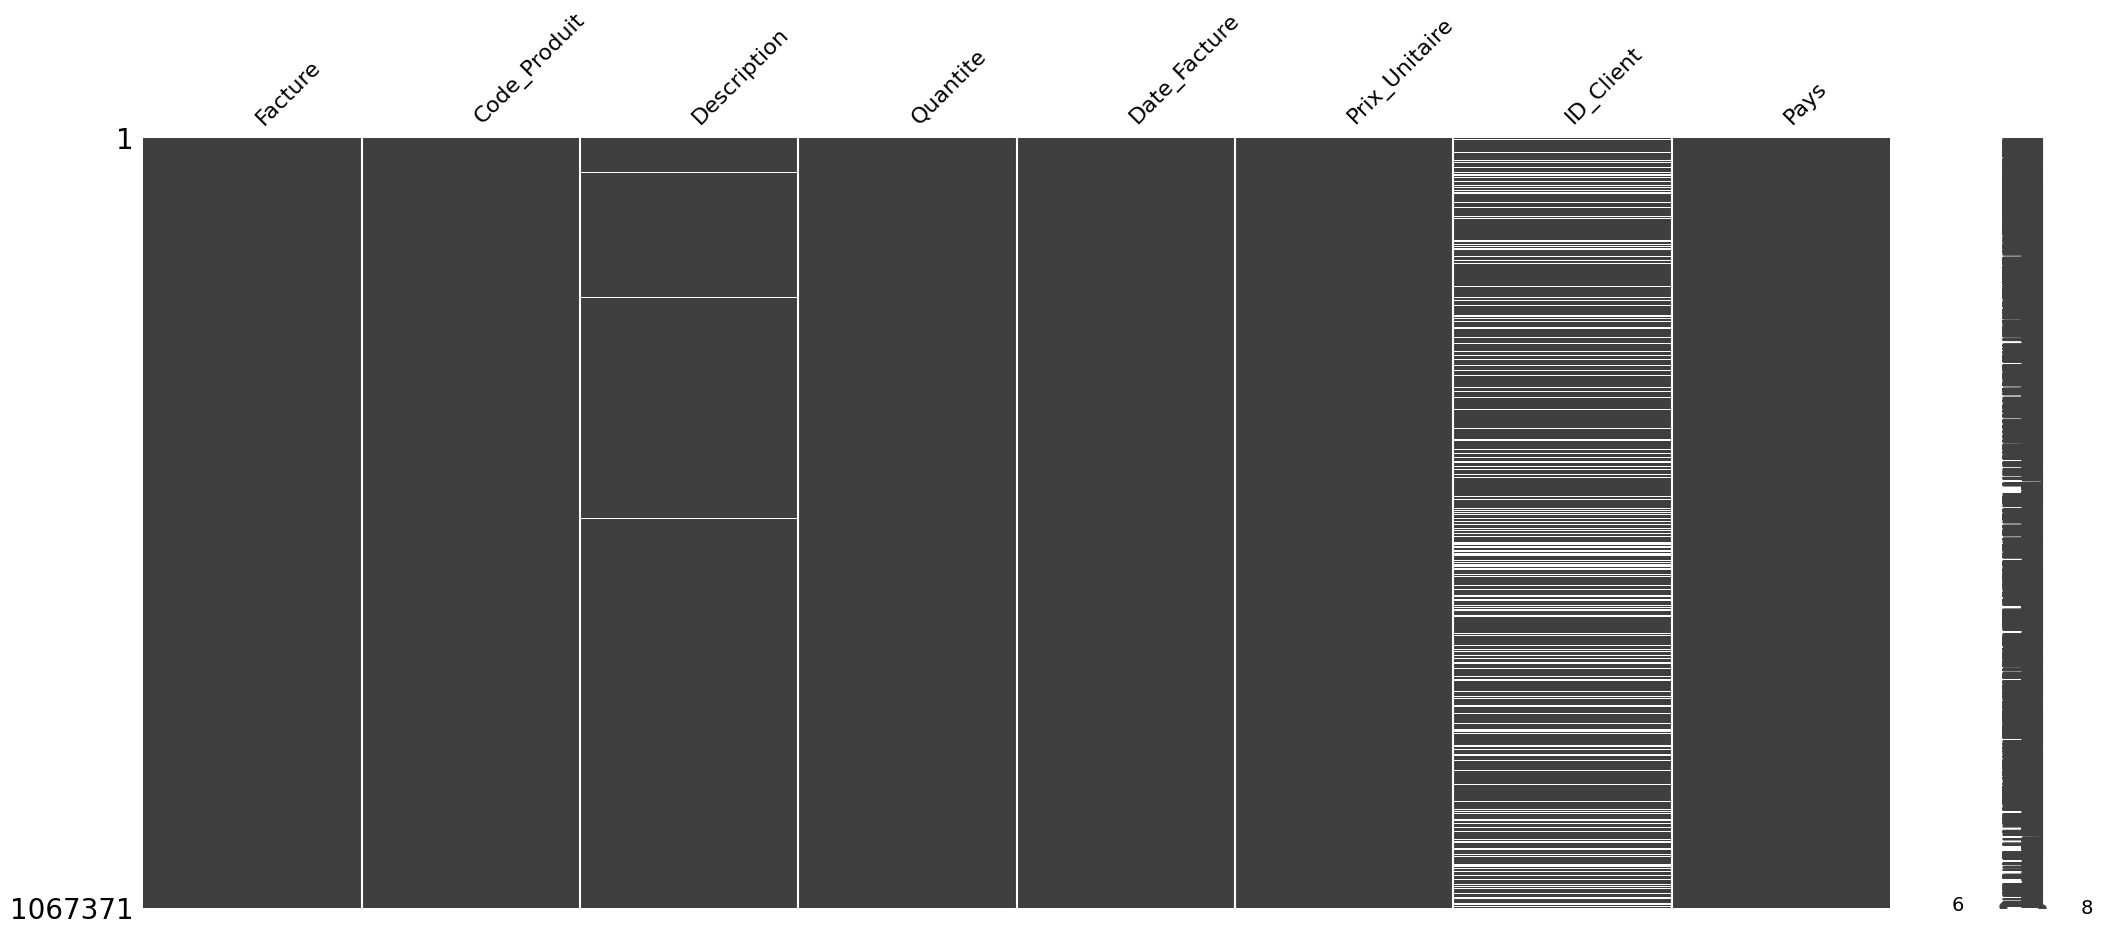

In [9]:
msno.matrix(df)

On remarque l'existence de valeurs maquantes 

#### Détection des doublons 

In [10]:
duplique= df.duplicated().sum()
print(f'Doublons dupliqués = {duplique}')

Doublons dupliqués = 34335


#### Distribution des variables 

In [9]:
num = df.select_dtypes(include=["int64","float64"])
print(num.columns)


Index(['Quantite', 'Prix_Unitaire', 'ID_Client'], dtype='object')


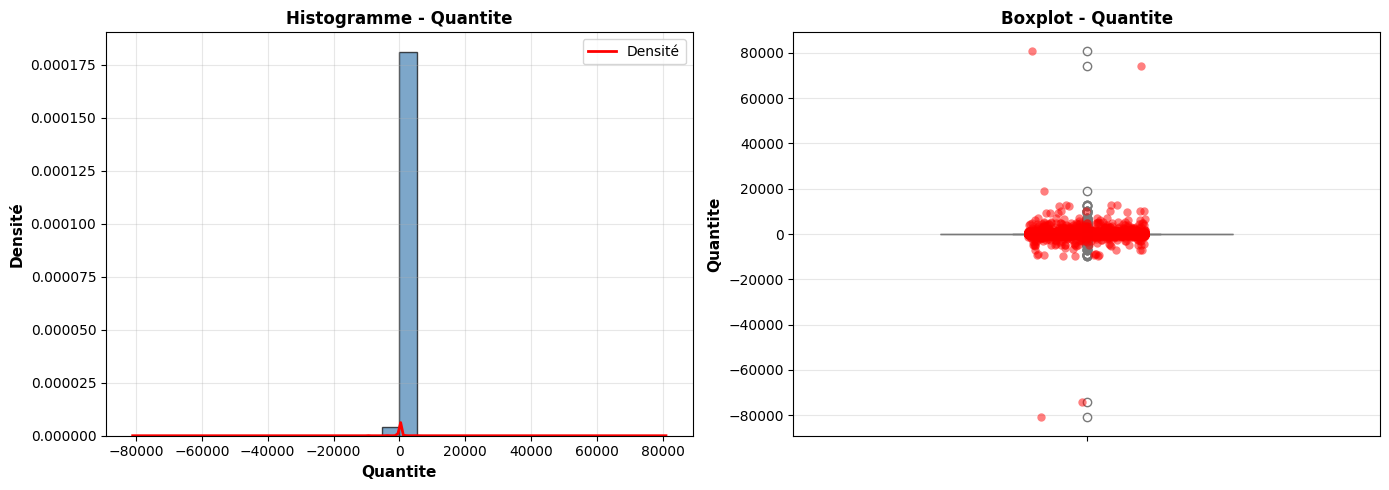

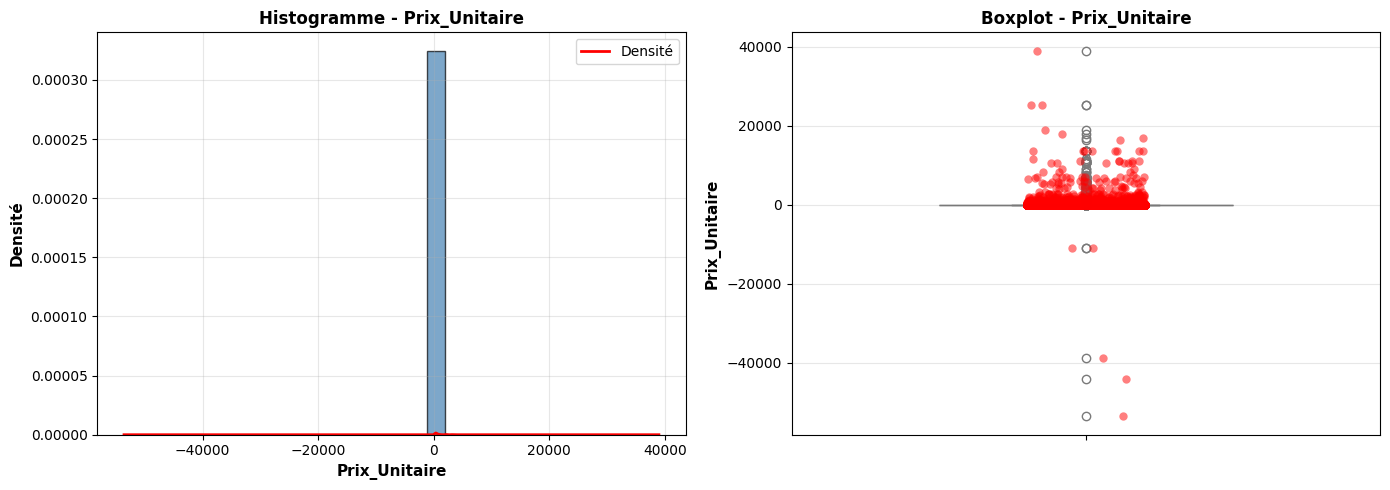

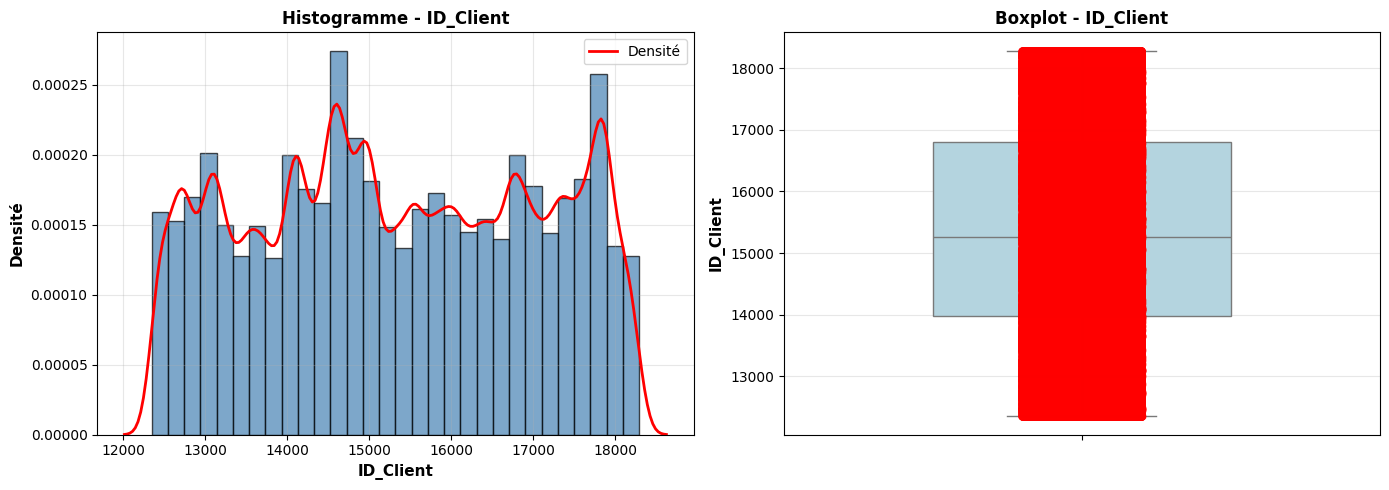

In [10]:
from pathlib import Path

images_dir = Path('images')
images_dir.mkdir(parents=True, exist_ok=True)

for var in num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme avec courbe de densité
    axes[0].hist(num[var], bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    sns.kdeplot(data=num[var], ax=axes[0], color='red', linewidth=2, label='Densité')
    axes[0].set_xlabel(var, fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Densité', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Histogramme - {var}', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Boxplot avec points
    sns.boxplot(data=num[var], ax=axes[1], color='lightblue', width=0.5)
    sns.stripplot(data=num[var], ax=axes[1], color='red', alpha=0.5, size=6)
    axes[1].set_ylabel(var, fontsize=11, fontweight='bold')
    axes[1].set_title(f'Boxplot - {var}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    fig.savefig(images_dir / f'{var}_distribution.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

Ces variables ne suivent potentiellement pas une loi normale et présente des outliers 

#### Corrélation des variables 


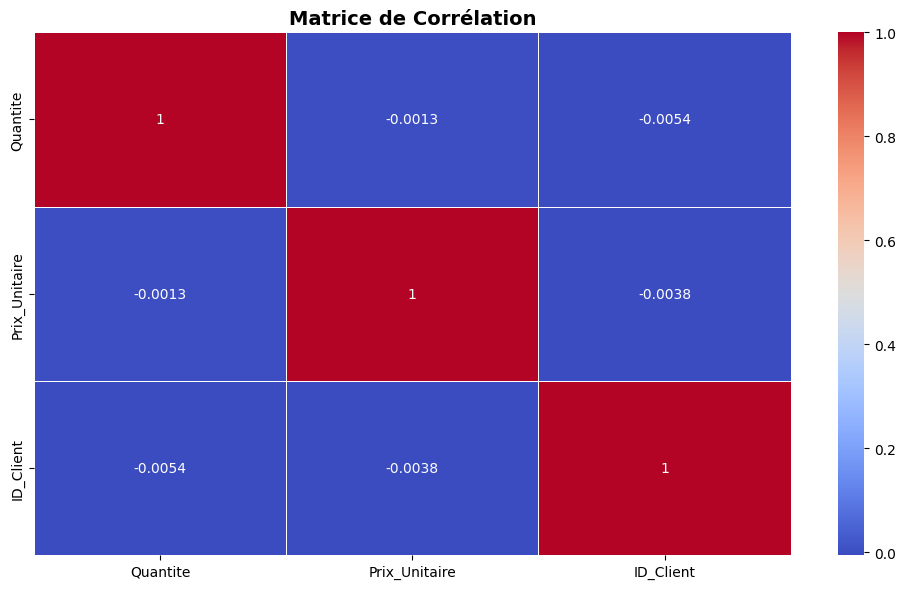

In [8]:
from pathlib import Path

images_dir = Path('images')
images_dir.mkdir(parents=True, exist_ok=True)

correlation = df.corr(method='pearson' , numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(images_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

#### Détection des outliers 

In [14]:
# sur le plan univarié 
# méthode IQR 
def detec_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    borne_infer = Q1 - (1.5 * IQR)
    borne_super = Q3 + (1.5 * IQR)

    return data[(data[column] < borne_infer) | (data[column] > borne_super)]

outliers = detec_outliers(df, 'ID_Client')
print('Outliers détectés')
print(outliers)

Outliers détectés
Empty DataFrame
Columns: [Facture, Code_Produit, Description, Quantite, Date_Facture, Prix_Unitaire, ID_Client, Pays]
Index: []


In [15]:
# Isolation Forest (sur variables numériques uniquement)
from sklearn.ensemble import IsolationForest

# 1) Garder seulement les colonnes numériques
X_iso = df.select_dtypes(include=[np.number]).copy()

# 2) Retirer une éventuelle colonne cible déjà créée
if 'Outlier' in X_iso.columns:
    X_iso = X_iso.drop(columns=['Outlier'])



iso_forest = IsolationForest(contamination=0.001, random_state=42)
outlier_labels = iso_forest.fit_predict(X_iso)

df['Outlier'] = outlier_labels
outliers = df[df['Outlier'] == -1]

print('Outliers détectés (Isolation Forest)')
n_outliers_iso = (outlier_labels == -1).sum()
print(f"Outliers détectés : {n_outliers_iso} ({n_outliers_iso/len(df)*100:.2f}%)")
print(f"Colonnes utilisées : {X_iso.shape[1]}")

Outliers détectés (Isolation Forest)
Outliers détectés : 1066 (0.10%)
Colonnes utilisées : 3


Une bonne façon de gérer les outliers est de traiter les modèles avec et sans les outliers afin de comprendre l'impact que ces derniers peuvent avoir sur le modele 

## Prétraitement des données 

#### Gestion des doublons 


In [5]:
print("_"*100)
print('Gestion des doublons')
print("_"*100)
print(f"Avant suppression des doublons {df.shape[0]:,}")
df = df.drop_duplicates()
print(f"Après suppression des doublons {df.shape[0]:,}")

____________________________________________________________________________________________________
Gestion des doublons
____________________________________________________________________________________________________
Avant suppression des doublons 1,067,371
Après suppression des doublons 1,033,036


In [6]:
print('_'*100)
print('Gestion des valeurs manquantes (règles métier)')
print('_'*100)

print('Avant traitement:')
print(df[['Description', 'ID_Client']].isna().sum())

# Description: très peu de valeurs manquantes -> suppression des lignes
df = df.dropna(subset=['Description']).copy()

# ID_Client: PAS d'imputation ici pour éviter le data leakage
# L'imputation des features est faite dans le pipeline après train_test_split

print('Après traitement:')
print(df[['Description', 'ID_Client']].isna().sum())
print('Shape après traitement:', df.shape)

____________________________________________________________________________________________________
Gestion des valeurs manquantes (règles métier)
____________________________________________________________________________________________________
Avant traitement:
Description      4275
ID_Client      235151
dtype: int64
Après traitement:
Description         0
ID_Client      230876
dtype: int64
Shape après traitement: (1028761, 8)


Afin d'éviter le data leakage la gestion des valeurs manquantes et des outliers  , l'encodage des variables catégorielles , la normalisation  se feront dans le pipeline

#### Feature engineering - Agrégation au niveau CLIENT (RFM) 
Pour une vraie segmentation client, nous passons de l'historique transactionnel à une table RFM client où chaque ligne représente 1 client unique.

In [15]:
# Créer une table au niveau CLIENT (une ligne = 1 client)
# Agrégation de l'historique transactionnel

# S'assurer que les colonnes RFM existent (sinon les créer)
df_prep = df.copy()

# Récence: jours depuis le dernier achat
if 'Recence' not in df_prep.columns:
    df_prep['Date_Facture'] = pd.to_datetime(df_prep['Date_Facture'], errors='coerce')
    date_reference = df_prep['Date_Facture'].max() + pd.Timedelta(days=1)
    recency_map = (df_prep.dropna(subset=['ID_Client', 'Date_Facture'])
                   .groupby('ID_Client')['Date_Facture'].max())
    recency_map = (date_reference - recency_map).dt.days
    df_prep['Recence'] = df_prep['ID_Client'].map(recency_map)

# Fréquence: nombre d'achats uniques par client
if 'frequency' not in df_prep.columns:
    frequency_map = df_prep.groupby('ID_Client')['Facture'].nunique()
    df_prep['frequency'] = df_prep['ID_Client'].map(frequency_map)

# TotalPrice: prix total par transaction
if 'TotalPrice' not in df_prep.columns:
    df_prep['TotalPrice'] = df_prep['Quantite'] * df_prep['Prix_Unitaire']

# Agrégation au niveau client
client_rfm = df_prep.dropna(subset=['ID_Client']).groupby('ID_Client').agg({
    'Recence': 'first',
    'frequency': 'first',
    'TotalPrice': 'sum',
    'Quantite': 'sum',
    'Pays': 'first'
}).reset_index()

print(f'Table client RFM créée: {client_rfm.shape}')
print(f'Nombre de clients uniques: {client_rfm.shape[0]}')
print(client_rfm.head(10))
print(client_rfm.describe())

Table client RFM créée: (5942, 6)
Nombre de clients uniques: 5942
   ID_Client  Recence  frequency  TotalPrice  Quantite            Pays
0    12346.0    326.0       17.0      -64.68        52  United Kingdom
1    12347.0      2.0        8.0     5633.32      3286         Iceland
2    12348.0     75.0        5.0     2019.40      2714         Finland
3    12349.0     19.0        5.0     4404.54      1619           Italy
4    12350.0    310.0        1.0      334.40       197          Norway
5    12351.0    375.0        1.0      300.93       261     Unspecified
6    12352.0     36.0       13.0     1889.21       658          Norway
7    12353.0    204.0        2.0      406.76       212         Bahrain
8    12354.0    232.0        1.0     1079.40       530           Spain
9    12355.0    214.0        2.0      947.61       543         Bahrain
          ID_Client      Recence    frequency     TotalPrice       Quantite
count   5942.000000  5942.000000  5942.000000    5942.000000    5942.000000
m

Dans le cadre de cette segmentation client, nous travaillons en apprentissage non supervisé, ce qui implique l’absence de variable cible (y) et l’utilisation exclusive des features (X).  
De plus, afin d’éviter toute fuite de données (data leakage), la standardisation est appliquée uniquement après le split des données en ensembles d’entraînement et de test, assurant ainsi une évaluation fiable des performances du modèle.

## Sélection des features 

Nous allons travailler avec toutes les variables dans un premier temps 

## Modélisation-Entrainement de modèles 

In [16]:
# Prétraitement du table client (train/test split + pipeline StandardScaler + OneHotEncoder)

# Séparer features et ID
X_client = client_rfm.drop(columns=['ID_Client'], errors='ignore')

# Train/test split (80/20 sur les clients)
X_client_train, X_client_test = train_test_split(X_client, test_size=0.2, random_state=42)

# Colonnes numériques et catégorielles dans la table client
num_cols_client = X_client_train.select_dtypes(include=['number']).columns
cat_cols_client = X_client_train.select_dtypes(include=['object', 'category', 'bool']).columns

# Réutiliser les pipelines (fit sur train)
numeric_pipeline_client = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline_client = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_client = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline_client, num_cols_client),
        ('cat', categorical_pipeline_client, cat_cols_client)
    ]
)

# Transformation
X_client_train_prep = preprocessor_client.fit_transform(X_client_train)
X_client_test_prep = preprocessor_client.transform(X_client_test)

print('='*60)
print('Prétraitement au niveau CLIENT')
print('='*60)
print(f'Num cols: {len(num_cols_client)} | Cat cols: {len(cat_cols_client)}')
print(f'Shape client train transformé: {X_client_train_prep.shape}')
print(f'Shape client test transformé : {X_client_test_prep.shape}')


Prétraitement au niveau CLIENT
Num cols: 4 | Cat cols: 1
Shape client train transformé: (4753, 44)
Shape client test transformé : (1189, 44)


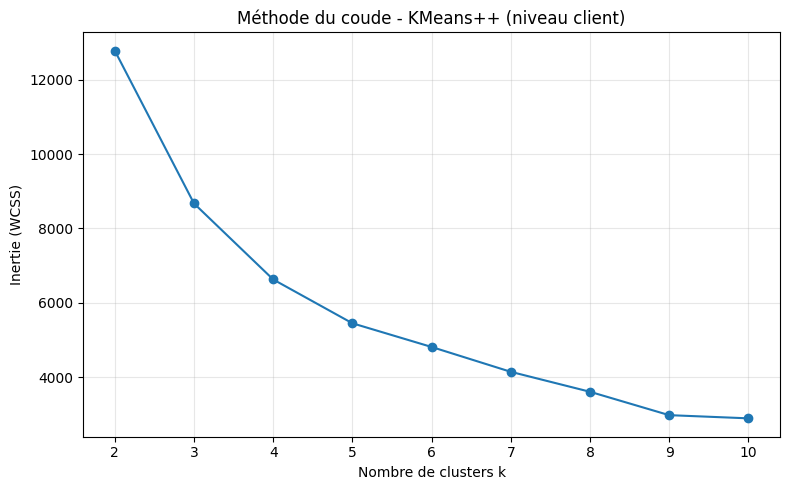

k retenu: 3


In [21]:
from pathlib import Path

images_dir = Path('images')
images_dir.mkdir(parents=True, exist_ok=True)

# Méthode du coude sur les données CLIENT (X_model_client)
k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km_elbow = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    km_elbow.fit(X_model_client)
    inertias.append(km_elbow.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Méthode du coude - KMeans++ (niveau client)')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (WCSS)')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(images_dir / 'elbow_method_client.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

optimal_k = 3  # remplace par le k lu sur le coude
print(f'k retenu: {optimal_k}')

In [18]:
# Benchmark final (niveau CLIENT) : KMeans++, CAH, DBSCAN
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np
from scipy import sparse

# 1) Sous-échantillon pour accélérer
max_samples = 15000
if X_client_train_prep.shape[0] > max_samples:
    rng = np.random.default_rng(42)
    idx = rng.choice(X_client_train_prep.shape[0], size=max_samples, replace=False)
    X_bench_client = X_client_train_prep[idx]
else:
    X_bench_client = X_client_train_prep

# 2) Réduction de dimension (utile si matrice sparse large)
if sparse.issparse(X_bench_client):
    n_comp = min(50, X_bench_client.shape[1] - 1)
    if n_comp >= 2:
        svd_client = TruncatedSVD(n_components=n_comp, random_state=42)
        X_model_client = svd_client.fit_transform(X_bench_client)
    else:
        X_model_client = X_bench_client.toarray()
else:
    X_model_client = X_bench_client

def evaluate_labels(model_name, labels):
    mask = labels != -1
    unique_labels = np.unique(labels[mask]) if mask.any() else np.array([])

    if len(unique_labels) >= 2 and mask.sum() >= 2:
        sil = silhouette_score(X_model_client[mask], labels[mask])
        dbi = davies_bouldin_score(X_model_client[mask], labels[mask])
    else:
        sil = np.nan
        dbi = np.nan

    return {
        'Model': model_name,
        'n_clusters': int(len(unique_labels)),
        'noise_%': float((labels == -1).mean() * 100),
        'silhouette': sil,
        'davies_bouldin': dbi
    }

results = []

# KMeans++ : tuning sur k
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels_km = km.fit_predict(X_model_client)
    res = evaluate_labels(f'KMeans++ (k={k})', labels_km)
    results.append(res)

# CAH : tuning sur k
for k in [3, 4, 5, 6]:
    cah = AgglomerativeClustering(n_clusters=k)
    labels_cah = cah.fit_predict(X_model_client)
    res = evaluate_labels(f'CAH (k={k})', labels_cah)
    results.append(res)

# DBSCAN : tuning simple de eps
for eps in [0.8, 1.0, 1.2, 1.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels_db = db.fit_predict(X_model_client)
    res = evaluate_labels(f'DBSCAN (eps={eps})', labels_db)
    results.append(res)

results_df = pd.DataFrame(results).sort_values(by='silhouette', ascending=False, na_position='last')
print('Shape benchmark (client):', X_model_client.shape)
print('Top 8 configurations:')
results_df.head(8)

Shape benchmark (client): (4753, 43)
Top 8 configurations:


,Model,n_clusters,noise_%,silhouette,davies_bouldin
2,KMeans++ (k=5),5,0.0,0.549935,0.826182
3,KMeans++ (k=6),6,0.0,0.548810,0.769610
1,KMeans++ (k=4),4,0.0,0.534534,0.735004
7,CAH (k=6),6,0.0,0.528870,0.695930
6,CAH (k=5),5,0.0,0.528239,0.740266
0,KMeans++ (k=3),3,0.0,0.521065,0.696239
5,CAH (k=4),4,0.0,0.511043,0.578249
4,CAH (k=3),3,0.0,0.510837,0.693282


In [31]:
# Validation stricte selon KPI métier (niveau CLIENT)
# Contraintes ajustées pour données client: silhouette >= 0.50, DBI <= 0.85, 3<=n_clusters<=6, min cluster >= seuil (%)
kpi_rows = []
min_cluster_threshold_pct = 0.005
silhouette_threshold = 0.50
dbi_threshold = 0.85

def cluster_distribution_info(labels):
    labels = np.asarray(labels)
    mask = labels != -1
    valid_labels = labels[mask]
    if valid_labels.size == 0:
        return 0, 0.0, 100.0
    unique, counts = np.unique(valid_labels, return_counts=True)
    shares = counts / counts.sum() * 100
    n_clusters = len(unique)
    min_share = float(shares.min())
    noise_pct = float((labels == -1).mean() * 100)
    return n_clusters, min_share, noise_pct

model_candidates = []
for k in [3, 4, 5, 6]:
    model_candidates.append((f'KMeans++ (k={k})', KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)))
for k in [3, 4, 5, 6]:
    model_candidates.append((f'CAH (k={k})', AgglomerativeClustering(n_clusters=k)))
for eps in [0.8, 1.0, 1.2, 1.5]:
    model_candidates.append((f'DBSCAN (eps={eps})', DBSCAN(eps=eps, min_samples=10)))

for name, model in model_candidates:
    labels = model.fit_predict(X_model_client)
    mask = labels != -1
    unique_labels = np.unique(labels[mask]) if mask.any() else np.array([])

    if len(unique_labels) >= 2 and mask.sum() >= 2:
        sil = float(silhouette_score(X_model_client[mask], labels[mask]))
        dbi = float(davies_bouldin_score(X_model_client[mask], labels[mask]))
    else:
        sil = np.nan
        dbi = np.nan

    n_clusters, min_share, noise_pct = cluster_distribution_info(labels)

    pass_sil = bool(np.isfinite(sil) and sil >= silhouette_threshold)
    pass_dbi = bool(np.isfinite(dbi) and dbi <= dbi_threshold)
    pass_k = bool(3 <= n_clusters <= 6)
    pass_size = bool(min_share >= min_cluster_threshold_pct)
    pass_all = pass_sil and pass_dbi and pass_k and pass_size

    kpi_rows.append({
        'Model': name,
        'n_clusters': n_clusters,
        'min_cluster_%': min_share,
        'noise_%': noise_pct,
        'silhouette': sil,
        'davies_bouldin': dbi,
        'PASS_all_KPI': pass_all
    })

kpi_df = pd.DataFrame(kpi_rows).sort_values(by=['PASS_all_KPI', 'silhouette'], ascending=[False, False])
print(f'Seuil min_cluster_% utilisé: {min_cluster_threshold_pct}%')
print(f'Seuil silhouette utilisé: {silhouette_threshold}')
print(f'Seuil DBI utilisé: {dbi_threshold}')
print('Modèles qui passent tous les KPI:')
display(kpi_df[kpi_df['PASS_all_KPI']].head(10))
print('Top global (même si certains KPI échouent):')
display(kpi_df.head(10))

Seuil min_cluster_% utilisé: 0.005%
Seuil silhouette utilisé: 0.5
Seuil DBI utilisé: 0.85
Modèles qui passent tous les KPI:


,Model,n_clusters,min_cluster_%,noise_%,silhouette,davies_bouldin,PASS_all_KPI
2,KMeans++ (k=5),5,0.084157,0.0,0.549935,0.826182,True
3,KMeans++ (k=6),6,0.084157,0.0,0.548810,0.769610,True
1,KMeans++ (k=4),4,0.084157,0.0,0.534534,0.735004,True
7,CAH (k=6),6,0.021039,0.0,0.528870,0.695930,True
6,CAH (k=5),5,0.021039,0.0,0.528239,0.740266,True
0,KMeans++ (k=3),3,0.273511,0.0,0.521065,0.696239,True
5,CAH (k=4),4,0.021039,0.0,0.511043,0.578249,True
4,CAH (k=3),3,0.294551,0.0,0.510837,0.693282,True


Top global (même si certains KPI échouent):


,Model,n_clusters,min_cluster_%,noise_%,silhouette,davies_bouldin,PASS_all_KPI
2,KMeans++ (k=5),5,0.084157,0.000000,0.549935,0.826182,True
3,KMeans++ (k=6),6,0.084157,0.000000,0.548810,0.769610,True
1,KMeans++ (k=4),4,0.084157,0.000000,0.534534,0.735004,True
7,CAH (k=6),6,0.021039,0.000000,0.528870,0.695930,True
6,CAH (k=5),5,0.021039,0.000000,0.528239,0.740266,True
0,KMeans++ (k=3),3,0.273511,0.000000,0.521065,0.696239,True
5,CAH (k=4),4,0.021039,0.000000,0.511043,0.578249,True
4,CAH (k=3),3,0.294551,0.000000,0.510837,0.693282,True
9,DBSCAN (eps=1.0),9,0.220216,4.460341,0.188154,1.060390,False
10,DBSCAN (eps=1.2),10,0.218531,3.723964,0.184940,1.183530,False


In [ ]:
# Clustering au niveau CLIENT : réduction PCA + KMeans++ (k choisi via KPI) + visualisation
# IMPORTANT: On cluster la totalité du dataset client
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import sparse
import pandas as pd
import numpy as np
import plotly.express as px

# 0) Choisir automatiquement k depuis le contrôle KPI (meilleur KMeans qui passe)
k_final = 3  # fallback
if 'kpi_df' in globals() and not kpi_df.empty:
    kmeans_pass = kpi_df[(kpi_df['PASS_all_KPI']) & (kpi_df['Model'].str.contains(r'KMeans\+\+'))]
    if not kmeans_pass.empty:
        best_model_name = kmeans_pass.sort_values('silhouette', ascending=False).iloc[0]['Model']
        k_final = int(best_model_name.split('k=')[1].split(')')[0])

print(f'k final retenu via KPI: {k_final}')

# 1) Préparer le dataset COMPLET client
X_client_complete = client_rfm.drop(columns=['ID_Client'], errors='ignore')

# Utiliser le preprocessor déjà entraîné sur train client
X_client_complete_prep = preprocessor_client.transform(X_client_complete)
print(f'Shape du dataset client COMPLET avant réduction: {X_client_complete_prep.shape}')

# 2) Réduction
if sparse.issparse(X_client_complete_prep):
    X_client_complete_dense = X_client_complete_prep.toarray()
else:
    X_client_complete_dense = X_client_complete_prep

# 3) PCA
pca_client = PCA(n_components=0.95, random_state=42)
X_client_pca_complete = pca_client.fit_transform(X_client_complete_dense)
print(f'Shape après PCA: {X_client_pca_complete.shape}')
print(f'Variance expliquée: {pca_client.explained_variance_ratio_.sum():.4f}')

# 4) Clustering final avec le k retenu
kmeans_final_client = KMeans(n_clusters=k_final, init='k-means++', n_init='auto', random_state=42)
labels_client = kmeans_final_client.fit_predict(X_client_pca_complete)
print(f'Labels assigned to {len(labels_client)} clients')

# 5) t-SNE pour visualiser
max_tsne_samples_client = min(8000, len(labels_client))
if len(labels_client) > max_tsne_samples_client:
    rng = np.random.default_rng(42)
    idx_tsne = rng.choice(len(labels_client), size=max_tsne_samples_client, replace=False)
    X_tsne_input_client = X_client_pca_complete[idx_tsne]
    labels_tsne_client = labels_client[idx_tsne]
else:
    X_tsne_input_client = X_client_pca_complete
    labels_tsne_client = labels_client

tsne_client = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne_client = tsne_client.fit_transform(X_tsne_input_client)

viz_df_client = pd.DataFrame({
    'tSNE_1': X_tsne_client[:, 0],
    'tSNE_2': X_tsne_client[:, 1],
    'Cluster': labels_tsne_client.astype(str)
})

fig_client = px.scatter(
    viz_df_client,
    x='tSNE_1',
    y='tSNE_2',
    color='Cluster',
    title=f't-SNE 2D des clusters CLIENTS (KMeans++ k={k_final})',
    opacity=0.7,
    width=950,
    height=600
)
fig_client.update_traces(marker=dict(size=5))
fig_client.show()

# Sauvegarde PNG uniquement (sans HTML)
images_dir = Path('images')
images_dir.mkdir(parents=True, exist_ok=True)
try:
    fig_client.write_image(images_dir / 'tsne_clusters_clients.png')
except Exception as e:
    print(f'Export PNG Plotly non disponible ({e}). Installe/maj kaleido pour activer l\'export PNG.')

cluster_pct_client = (pd.Series(labels_client).value_counts(normalize=True).sort_index() * 100).round(2)
print('\nRépartition des clusters (%) au NIVEAU CLIENT :')
print(cluster_pct_client)

k final retenu via KPI: 3
Shape du dataset client COMPLET avant réduction: (5942, 44)
Shape après PCA: (5942, 4)
Variance expliquée: 0.9609
Labels assigned to 5942 clients



Répartition des clusters (%) au NIVEAU CLIENT :
0    34.65
1    65.06
2     0.29
Name: proportion, dtype: float64


In [35]:
# Profilage marketing des segments CLIENTS (labels issus de KMeans++ k=3 sur PCA)
# Utiliser client_rfm (1 client = 1 ligne) + labels_client

profil_df_client = client_rfm.copy().reset_index(drop=True)
profil_df_client['Cluster'] = labels_client

# Colonnes utiles pour le profilage
candidate_metrics_client = ['Recence', 'frequency', 'TotalPrice', 'Quantite']
available_metrics_client = [c for c in candidate_metrics_client if c in profil_df_client.columns]

named_agg_client = {'n_clients': ('Cluster', 'size')}
for metric in available_metrics_client:
    named_agg_client[metric] = (metric, 'mean')

segment_stats_client = profil_df_client.groupby('Cluster').agg(**named_agg_client).reset_index()
segment_stats_client['pct_clients'] = (segment_stats_client['n_clients'] / len(profil_df_client) * 100).round(2)

# Scores normalisés pour un profilage robuste
for metric in ['TotalPrice', 'frequency', 'Recence']:
    if metric not in segment_stats_client.columns:
        segment_stats_client[metric] = np.nan

def zscore(s):
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

segment_stats_client['z_total'] = zscore(segment_stats_client['TotalPrice'])
segment_stats_client['z_freq'] = zscore(segment_stats_client['frequency'])
segment_stats_client['z_rec'] = zscore(segment_stats_client['Recence'])

# Heuristique: valeur client élevée = dépenses + fréquence - récence (moins récent = dormant)
segment_stats_client['value_score'] = segment_stats_client['z_total'] + segment_stats_client['z_freq'] - segment_stats_client['z_rec']

# Attribution des personas marketing
persona_map_client = {}

# Trouver les clusters VIP (value_score max), Dormants (recence max = moins actifs), Nouveaux/Occasionnels
vip_cluster_client = int(segment_stats_client.sort_values('value_score', ascending=False).iloc[0]['Cluster'])
dormant_cluster_client = int(segment_stats_client.sort_values('z_rec', ascending=False).iloc[0]['Cluster'])

remaining_client = [c for c in segment_stats_client['Cluster'].tolist() if c not in [vip_cluster_client, dormant_cluster_client]]
if len(remaining_client) >= 1:
    new_cluster_client = int(segment_stats_client[segment_stats_client['Cluster'].isin(remaining_client)].sort_values('z_rec', ascending=True).iloc[0]['Cluster'])
else:
    new_cluster_client = None

if len(remaining_client) >= 2:
    occ_cluster_client = [c for c in remaining_client if c != new_cluster_client][0]
else:
    occ_cluster_client = None

# Assignation des personas avec stratégie marketing
persona_map_client[vip_cluster_client] = ('👑 VIP Fidèles', 'Programme de fidélité exclusif + accès early-bird')
persona_map_client[dormant_cluster_client] = ('😴 Clients Dormants', 'Email de réactivation + code promo spécial')
if new_cluster_client is not None:
    persona_map_client[int(new_cluster_client)] = ('🆕 Nouveaux Clients', 'Onboarding complet + first-purchase incentive')
if occ_cluster_client is not None:
    persona_map_client[int(occ_cluster_client)] = ('💰 Acheteurs Occasionnels', 'Offres premium ponctuelles + bundle deals')

# Fallback générique
for c in segment_stats_client['Cluster'].tolist():
    if int(c) not in persona_map_client:
        persona_map_client[int(c)] = (f'🎯 Segment {int(c)}', 'Campagne personnalisée basée sur le comportement RFM')

# Tableau marketing
profilage_marketing_client = segment_stats_client[['Cluster']].copy()
profilage_marketing_client[['Nom', 'Strategie']] = profilage_marketing_client['Cluster'].apply(
    lambda c: pd.Series(persona_map_client[int(c)])
)

profilage_marketing_client = profilage_marketing_client.sort_values('Cluster').reset_index(drop=True)
print('='*70)
print('Tableau de profilage marketing des segments CLIENTS :')
print('='*70)
display(profilage_marketing_client)

# Tableau enrichi avec métriques RFM
cols_out_client = ['Cluster', 'n_clients', 'pct_clients'] + [c for c in ['Recence', 'frequency', 'TotalPrice', 'Quantite'] if c in segment_stats_client.columns]
profilage_detail_client = segment_stats_client[cols_out_client].merge(profilage_marketing_client, on='Cluster', how='left')
print('\n' + '='*70)
print('Profilage détaillé (avec métriques RFM moyennes) :')
print('='*70)
display(profilage_detail_client.sort_values('Cluster').reset_index(drop=True))


Tableau de profilage marketing des segments CLIENTS :


,Cluster,Nom,Strategie
0,0,😴 Clients Dormants,Email de réactivation + code promo spécial
1,1,💰 Acheteurs Occasionnels,Offres premium ponctuelles + bundle deals
2,2,🎯 Segment 2,Campagne personnalisée basée sur le comporteme...
3,3,🆕 Nouveaux Clients,Onboarding complet + first-purchase incentive
4,4,👑 VIP Fidèles,Programme de fidélité exclusif + accès early-bird



Profilage détaillé (avec métriques RFM moyennes) :


,Cluster,n_clients,pct_clients,Recence,frequency,TotalPrice,Quantite,Nom,Strategie
0,0,2036,34.26,466.052554,2.567780,594.159800,383.570236,😴 Clients Dormants,Email de réactivation + code promo spécial
1,1,3858,64.93,65.963971,8.771903,2769.448235,1636.287973,💰 Acheteurs Occasionnels,Offres premium ponctuelles + bundle deals
2,2,6,0.10,109.666667,171.666667,198919.228333,151790.000000,🎯 Segment 2,Campagne personnalisée basée sur le comporteme...
3,3,40,0.67,41.250000,111.475000,60974.477075,41932.750000,🆕 Nouveaux Clients,Onboarding complet + first-purchase incentive
4,4,2,0.03,1.500000,158.500000,560778.645000,276165.000000,👑 VIP Fidèles,Programme de fidélité exclusif + accès early-bird
